# Desafio 1

In [20]:
variables_map = ['SP', 'RJ', 'MG', 'ES']

domains_map = {
    'SP': ['Vermelho', 'Verde', 'Azul'],
    'RJ': ['Vermelho', 'Verde', 'Azul'],
    'MG': ['Vermelho', 'Verde', 'Azul'],
    'ES': ['Vermelho', 'Verde', 'Azul']
}

neighbors_map = {
    'SP': ['RJ', 'MG'],
    'RJ': ['SP', 'MG', 'ES'],
    'MG': ['SP', 'RJ', 'ES'],
    'ES': ['RJ', 'MG']
}

In [21]:
def is_consistent_map(var, value, assignment):
    for neighbor in neighbors_map[var]:
        if neighbor in assignment and assignment[neighbor] == value:
            return False
    return True

In [22]:
def backtracking_map(assignment):
    if len(assignment) == len(variables_map):
        return assignment

    unassigned = [v for v in variables_map if v not in assignment]
    var = unassigned[0]

    for value in domains_map[var]:
        if is_consistent_map(var, value, assignment):
            assignment[var] = value
            result = backtracking_map(assignment)
            if result:
                return result
            del assignment[var]

    return None

In [23]:
print("===== COLORAÇÃO DO MAPA =====")
solution_map = backtracking_map({})
print(solution_map)

===== COLORAÇÃO DO MAPA =====
{'SP': 'Vermelho', 'RJ': 'Verde', 'MG': 'Azul', 'ES': 'Vermelho'}



===== VISUALIZAÇÃO DO MAPA =====


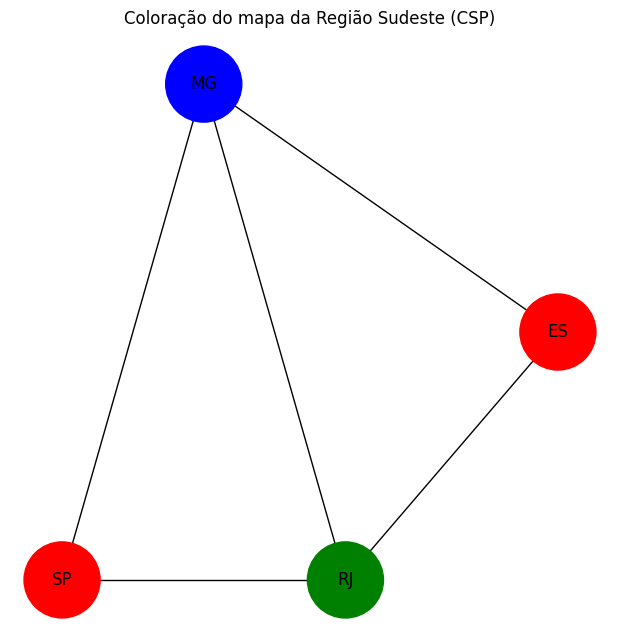

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
# ==========================================
# PLOT DO GRAFO DO SUDESTE
# ==========================================

print("\n===== VISUALIZAÇÃO DO MAPA =====")

G = nx.Graph()

# Estados
G.add_nodes_from(['SP','RJ','MG','ES'])

# Fronteiras
G.add_edges_from([
    ('SP','RJ'),
    ('SP','MG'),
    ('RJ','MG'),
    ('RJ','ES'),
    ('MG','ES')
])

# Converter cores
color_map = {
    'Vermelho': 'red',
    'Verde': 'green',
    'Azul': 'blue'
}

node_colors = [color_map[solution_map[node]] for node in G.nodes()]

# Posições para parecer um mapa
pos = {
    'MG': (0.5,1),
    'SP': (0.3,0.4),
    'RJ': (0.7,0.4),
    'ES': (1,0.7)
}

plt.figure(figsize=(6,6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=3000,
    font_size=12
)

plt.title("Coloração do mapa da Região Sudeste (CSP)")
plt.show()

# Desafio 2

In [25]:
import time
import copy

In [26]:
def print_sudoku(assignment):
    board = [[0]*9 for _ in range(9)]
    for (r,c), v in assignment.items():
        board[r][c] = v

    for i in range(9):
        if i % 3 == 0 and i != 0:
            print("-"*21)
        for j in range(9):
            if j % 3 == 0 and j != 0:
                print("|", end=" ")
            print(board[i][j], end=" ")
        print()

In [27]:
def create_domains(board):
    domains = {}
    for row in range(9):
        for col in range(9):
            value = board[row*9 + col]
            if value == 0:
                domains[(row, col)] = list(range(1, 10))
            else:
                domains[(row, col)] = [value]
    return domains

In [28]:
def initial_assignment(board):
    assignment = {}
    for row in range(9):
        for col in range(9):
            value = board[row*9 + col]
            if value != 0:
                assignment[(row, col)] = value
    return assignment

In [29]:
def is_valid(var, value, assignment):
    row, col = var

    for (r, c), v in assignment.items():
        if v == value:
            if r == row or c == col:
                return False
            if (r//3 == row//3) and (c//3 == col//3):
                return False

    return True

In [30]:
#BACKTRACKING PURO
def backtracking_sudoku(assignment, domains, metrics):
    if len(assignment) == 81:
        return assignment

    unassigned = [v for v in domains if v not in assignment]
    var = unassigned[0]

    metrics["nodes"] += 1

    for value in domains[var]:
        if is_valid(var, value, assignment):
            assignment[var] = value
            result = backtracking_sudoku(assignment, domains, metrics)
            if result:
                return result
            del assignment[var]

    metrics["backtracks"] += 1
    return None

In [31]:
#BACKTRACKING COM MVR
def select_mrv_variable(assignment, domains):
    unassigned = [v for v in domains if v not in assignment]

    return min(unassigned, key=lambda var: len([
        value for value in domains[var]
        if is_valid(var, value, assignment)
    ]))

def backtracking_mrv(assignment, domains, metrics):
    if len(assignment) == 81:
        return assignment

    var = select_mrv_variable(assignment, domains)

    metrics["nodes"] += 1

    for value in domains[var]:
        if is_valid(var, value, assignment):
            assignment[var] = value
            result = backtracking_mrv(assignment, domains, metrics)
            if result:
                return result
            del assignment[var]

    metrics["backtracks"] += 1
    return None

In [32]:
sudoku_iniciante = [
5, 3, 0, 0, 7, 0, 0, 0, 0,
6, 0, 0, 1, 9, 5, 0, 0, 0,
0, 9, 8, 0, 0, 0, 0, 6, 0,
8, 0, 0, 0, 6, 0, 0, 0, 3,
4, 0, 0, 8, 0, 3, 0, 0, 1,
7, 0, 0, 0, 2, 0, 0, 0, 6,
0, 6, 0, 0, 0, 0, 2, 8, 0,
0, 0, 0, 4, 1, 9, 0, 0, 5,
0, 0, 0, 0, 8, 0, 0, 7, 9
]

In [33]:
sudoku_intermediario = [
0,0,5,3,0,0,0,0,0,
8,0,0,0,0,0,0,2,0,
0,7,0,0,1,0,5,0,0,
4,0,0,0,0,5,3,0,0,
0,1,0,0,7,0,0,0,6,
0,0,3,2,0,0,0,8,0,
0,6,0,5,0,0,0,0,9,
0,0,4,0,0,0,0,3,0,
0,0,0,0,0,9,7,0,0
]

In [34]:
sudoku_hard = [
    8, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 3, 6, 0, 0, 0, 0, 0,
    0, 7, 0, 0, 9, 0, 2, 0, 0,
    0, 5, 0, 0, 0, 7, 0, 0, 0,
    0, 0, 0, 0, 4, 5, 7, 0, 0,
    0, 0, 0, 1, 0, 0, 0, 3, 0,
    0, 0, 1, 0, 0, 0, 0, 6, 8,
    0, 0, 8, 5, 0, 0, 0, 1, 0,
    0, 9, 0, 0, 0, 0, 4, 0, 0
]

In [35]:
print("\n===== SUDOKU Iniciante - BACKTRACKING PURO =====")
domains = create_domains(sudoku_iniciante)
assignment = initial_assignment(sudoku_iniciante)

metrics_bt = {"nodes": 0, "backtracks": 0}
start = time.time()
solution_bt = backtracking_sudoku(copy.deepcopy(assignment), domains, metrics_bt)
end = time.time()

print_sudoku(solution_bt)
print("Tempo:", end - start)
print("Nós:", metrics_bt["nodes"])
print("Backtracks:", metrics_bt["backtracks"])


===== SUDOKU Iniciante - BACKTRACKING PURO =====
5 3 4 | 6 7 8 | 9 1 2 
6 7 2 | 1 9 5 | 3 4 8 
1 9 8 | 3 4 2 | 5 6 7 
---------------------
8 5 9 | 7 6 1 | 4 2 3 
4 2 6 | 8 5 3 | 7 9 1 
7 1 3 | 9 2 4 | 8 5 6 
---------------------
9 6 1 | 5 3 7 | 2 8 4 
2 8 7 | 4 1 9 | 6 3 5 
3 4 5 | 2 8 6 | 1 7 9 
Tempo: 0.06957626342773438
Nós: 4208
Backtracks: 4157


In [36]:
print("\n===== SUDOKU Intermediario - BACKTRACKING PURO =====")
domains = create_domains(sudoku_intermediario)
assignment = initial_assignment(sudoku_intermediario)

metrics_bt = {"nodes": 0, "backtracks": 0}
start = time.time()
solution_bt = backtracking_sudoku(copy.deepcopy(assignment), domains, metrics_bt)
end = time.time()

print_sudoku(solution_bt)
print("Tempo:", end - start)
print("Nós:", metrics_bt["nodes"])
print("Backtracks:", metrics_bt["backtracks"])


===== SUDOKU Intermediario - BACKTRACKING PURO =====
1 4 5 | 3 2 7 | 6 9 8 
8 3 9 | 6 5 4 | 1 2 7 
6 7 2 | 9 1 8 | 5 4 3 
---------------------
4 9 6 | 1 8 5 | 3 7 2 
2 1 8 | 4 7 3 | 9 5 6 
7 5 3 | 2 9 6 | 4 8 1 
---------------------
3 6 7 | 5 4 2 | 8 1 9 
9 8 4 | 7 6 1 | 2 3 5 
5 2 1 | 8 3 9 | 7 6 4 
Tempo: 0.14617085456848145
Nós: 10007
Backtracks: 9949


In [37]:
print("\n===== SUDOKU Hard - BACKTRACKING PURO =====")
domains = create_domains(sudoku_hard)
assignment = initial_assignment(sudoku_hard)

metrics_bt = {"nodes": 0, "backtracks": 0}
start = time.time()
solution_bt = backtracking_sudoku(copy.deepcopy(assignment), domains, metrics_bt)
end = time.time()

print_sudoku(solution_bt)
print("Tempo:", end - start)
print("Nós:", metrics_bt["nodes"])
print("Backtracks:", metrics_bt["backtracks"])


===== SUDOKU Hard - BACKTRACKING PURO =====
8 1 2 | 7 5 3 | 6 4 9 
9 4 3 | 6 8 2 | 1 7 5 
6 7 5 | 4 9 1 | 2 8 3 
---------------------
1 5 4 | 2 3 7 | 8 9 6 
3 6 9 | 8 4 5 | 7 2 1 
2 8 7 | 1 6 9 | 5 3 4 
---------------------
5 2 1 | 9 7 4 | 3 6 8 
4 3 8 | 5 2 6 | 9 1 7 
7 9 6 | 3 1 8 | 4 5 2 
Tempo: 0.7380201816558838
Nós: 49558
Backtracks: 49498


In [38]:
print("\n===== SUDOKU iniciante - BACKTRACKING + MRV =====")
domains = create_domains(sudoku_iniciante)
assignment = initial_assignment(sudoku_iniciante)

metrics_mrv = {"nodes": 0, "backtracks": 0}
start = time.time()
solution_mrv = backtracking_mrv(copy.deepcopy(assignment), domains, metrics_mrv)
end = time.time()

print_sudoku(solution_mrv)
print("Tempo:", end - start)
print("Nós:", metrics_mrv["nodes"])
print("Backtracks:", metrics_mrv["backtracks"])


===== SUDOKU iniciante - BACKTRACKING + MRV =====
5 3 4 | 6 7 8 | 9 1 2 
6 7 2 | 1 9 5 | 3 4 8 
1 9 8 | 3 4 2 | 5 6 7 
---------------------
8 5 9 | 7 6 1 | 4 2 3 
4 2 6 | 8 5 3 | 7 9 1 
7 1 3 | 9 2 4 | 8 5 6 
---------------------
9 6 1 | 5 3 7 | 2 8 4 
2 8 7 | 4 1 9 | 6 3 5 
3 4 5 | 2 8 6 | 1 7 9 
Tempo: 0.014948368072509766
Nós: 51
Backtracks: 0


In [39]:
print("\n===== SUDOKU intermediario - BACKTRACKING + MRV =====")
domains = create_domains(sudoku_intermediario)
assignment = initial_assignment(sudoku_intermediario)

metrics_mrv = {"nodes": 0, "backtracks": 0}
start = time.time()
solution_mrv = backtracking_mrv(copy.deepcopy(assignment), domains, metrics_mrv)
end = time.time()

print_sudoku(solution_mrv)
print("Tempo:", end - start)
print("Nós:", metrics_mrv["nodes"])
print("Backtracks:", metrics_mrv["backtracks"])


===== SUDOKU intermediario - BACKTRACKING + MRV =====
1 4 5 | 3 2 7 | 6 9 8 
8 3 9 | 6 5 4 | 1 2 7 
6 7 2 | 9 1 8 | 5 4 3 
---------------------
4 9 6 | 1 8 5 | 3 7 2 
2 1 8 | 4 7 3 | 9 5 6 
7 5 3 | 2 9 6 | 4 8 1 
---------------------
3 6 7 | 5 4 2 | 8 1 9 
9 8 4 | 7 6 1 | 2 3 5 
5 2 1 | 8 3 9 | 7 6 4 
Tempo: 0.20046305656433105
Nós: 542
Backtracks: 484


In [40]:
print("\n===== SUDOKU Hard - BACKTRACKING + MRV =====")
domains = create_domains(sudoku_hard)
assignment = initial_assignment(sudoku_hard)

metrics_mrv = {"nodes": 0, "backtracks": 0}
start = time.time()
solution_mrv = backtracking_mrv(copy.deepcopy(assignment), domains, metrics_mrv)
end = time.time()

print_sudoku(solution_mrv)
print("Tempo:", end - start)
print("Nós:", metrics_mrv["nodes"])
print("Backtracks:", metrics_mrv["backtracks"])


===== SUDOKU Hard - BACKTRACKING + MRV =====
8 1 2 | 7 5 3 | 6 4 9 
9 4 3 | 6 8 2 | 1 7 5 
6 7 5 | 4 9 1 | 2 8 3 
---------------------
1 5 4 | 2 3 7 | 8 9 6 
3 6 9 | 8 4 5 | 7 2 1 
2 8 7 | 1 6 9 | 5 3 4 
---------------------
5 2 1 | 9 7 4 | 3 6 8 
4 3 8 | 5 2 6 | 9 1 7 
7 9 6 | 3 1 8 | 4 5 2 
Tempo: 3.934784412384033
Nós: 10101
Backtracks: 10041
